In [1]:
from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold)
from sklearn.feature_selection import (RFE, RFECV)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("diabetes_data_clean.csv")
data.head()
data['diabetes_class'].value_counts()

diabetes_class
1    320
0    200
Name: count, dtype: int64

In [3]:
# Split Train Test
y = data["diabetes_class"]
X = data.drop(columns = "diabetes_class")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=4308)


In [4]:
# Helper for evaluating results
def evaluate_model(model, name, X_tr, y_tr, X_te, y_te, cv):
    """Fit model, print metrics for both percentage-split and 10-fold CV."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    cm = confusion_matrix(y_te, y_pred)

    print(f"\n{'=' * 70}")
    print(f" {name}")
    print(f"{'=' * 70}")

    # --- Percentage Split (80/20) ---
    print(f"\n--- 80/20 Percentage Split ---")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC:       {auc:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"    {cm}")
    print(f"\n  Classification Report:")
    print(classification_report(y_te, y_pred, target_names=["Negative", "Positive"]))

    # --- 10-Fold Cross-Validation ---
    cv_acc = cross_val_score(model, np.vstack([X_tr, X_te]), np.hstack([y_tr, y_te]),
                             cv=cv, scoring="accuracy")
    cv_prec = cross_val_score(model, np.vstack([X_tr, X_te]), np.hstack([y_tr, y_te]),
                              cv=cv, scoring="precision")
    cv_rec = cross_val_score(model, np.vstack([X_tr, X_te]), np.hstack([y_tr, y_te]),
                             cv=cv, scoring="recall")
    cv_f1 = cross_val_score(model, np.vstack([X_tr, X_te]), np.hstack([y_tr, y_te]),
                            cv=cv, scoring="f1")
    cv_auc = cross_val_score(model, np.vstack([X_tr, X_te]), np.hstack([y_tr, y_te]),
                             cv=cv, scoring="roc_auc")

    print(f"--- 10-Fold Cross-Validation ---")
    print(f"  Accuracy:  {cv_acc.mean():.4f} (+/- {cv_acc.std():.4f})")
    print(f"  Precision: {cv_prec.mean():.4f} (+/- {cv_prec.std():.4f})")
    print(f"  Recall:    {cv_rec.mean():.4f} (+/- {cv_rec.std():.4f})")
    print(f"  F1-Score:  {cv_f1.mean():.4f} (+/- {cv_f1.std():.4f})")
    print(f"  AUC:       {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})")

    return model, y_pred, y_prob

In [5]:
# RFE with random forest for a fixed selected number of features
rfe_rf = RFE(RandomForestClassifier(n_estimators=100, criterion = "gini", random_state=4308, n_jobs=-1), 
          n_features_to_select = 5)
rfe_rf_model, rfe_rf_pred, rfe_rf_y_prob = evaluate_model(rfe_rf, "Recursive Feature Elimination for Random Forest", X_tr = X_train, y_tr = y_train, X_te = X_test, y_te = y_test, cv = 10)


 Recursive Feature Elimination for Random Forest

--- 80/20 Percentage Split ---
  Accuracy:  0.9519
  Precision: 0.9857
  Recall:    0.9452
  F1-Score:  0.9650
  AUC:       0.9925

  Confusion Matrix:
    [[30  1]
 [ 4 69]]

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.97      0.92        31
    Positive       0.99      0.95      0.97        73

    accuracy                           0.95       104
   macro avg       0.93      0.96      0.94       104
weighted avg       0.95      0.95      0.95       104

--- 10-Fold Cross-Validation ---
  Accuracy:  0.9346 (+/- 0.0414)
  Precision: 0.9657 (+/- 0.0289)
  Recall:    0.9281 (+/- 0.0685)
  F1-Score:  0.9447 (+/- 0.0377)
  AUC:       0.9753 (+/- 0.0200)


In [6]:
# Auto feature selection from cross validation
cv = StratifiedKFold(5)
estimator = RandomForestClassifier(n_estimators=100, random_state=4308)

rfecv_rf = RFECV(estimator = estimator, cv = cv)
rfecv_rf.fit(X_train, y_train)
selected_features_mask = rfecv_rf.get_support()
# Get the names of the selected features
selected_features_rf = X.columns[selected_features_mask].tolist()

print(f"Optimal number of selected features: {len(selected_features_rf)}")
print("Selected Features:")
print(selected_features_rf)

Optimal number of selected features: 16
Selected Features:
['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'weakness', 'polyphagia', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'partial_paresis', 'muscle_stiffness', 'alopecia', 'obesity']


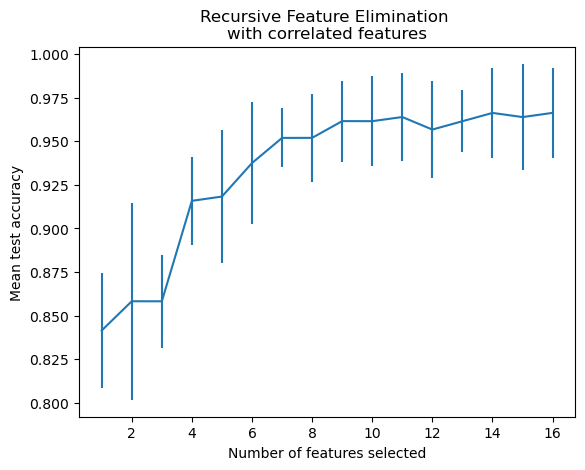

In [7]:
data = {
    key: value
    for key, value in rfecv_rf.cv_results_.items()
    if key in ["n_features", "mean_test_score", "std_test_score"]
}
cv_results = pd.DataFrame(data)
plt.figure()
plt.xlabel("Number of features selected")
plt.ylabel("Mean test accuracy")
plt.errorbar(
    x=cv_results["n_features"],
    y=cv_results["mean_test_score"],
    yerr=cv_results["std_test_score"],
)
plt.title("Recursive Feature Elimination \nwith correlated features")
plt.show()

In [9]:
# Evaluate RFE random forest with the optimal features
rfecv_rf_model, rfecv_rf_pred, rfecv_rf_prod = evaluate_model(rfecv_rf, "Recursive Feature Elimination Cross Validation for Random Forest", X_tr = X_train, y_tr = y_train, X_te = X_test, y_te = y_test, cv = 10)


 Recursive Feature Elimination Cross Validation for Random Forest

--- 80/20 Percentage Split ---
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  AUC:       1.0000

  Confusion Matrix:
    [[31  0]
 [ 0 73]]

  Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        31
    Positive       1.00      1.00      1.00        73

    accuracy                           1.00       104
   macro avg       1.00      1.00      1.00       104
weighted avg       1.00      1.00      1.00       104

--- 10-Fold Cross-Validation ---
  Accuracy:  0.9865 (+/- 0.0123)
  Precision: 0.9879 (+/- 0.0148)
  Recall:    0.9906 (+/- 0.0200)
  F1-Score:  0.9890 (+/- 0.0102)
  AUC:       0.9980 (+/- 0.0036)


In [10]:
# RFE with XGBoost for a fixed selected number of features
rfe_xg = RFE(XGBClassifier(n_estimators=100, random_state=4308, n_jobs=-1), n_features_to_select = 5)
rfe_xg_model, rfe_xg_pred, rfe_xg_y_prob = evaluate_model(rfe_xg, "Recursive Feature Elimination for Random Forest", X_tr = X_train, y_tr = y_train, X_te = X_test, y_te = y_test, cv = 10)


 Recursive Feature Elimination for Random Forest

--- 80/20 Percentage Split ---
  Accuracy:  0.9231
  Precision: 0.9851
  Recall:    0.9041
  F1-Score:  0.9429
  AUC:       0.9792

  Confusion Matrix:
    [[30  1]
 [ 7 66]]

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.97      0.88        31
    Positive       0.99      0.90      0.94        73

    accuracy                           0.92       104
   macro avg       0.90      0.94      0.91       104
weighted avg       0.93      0.92      0.92       104

--- 10-Fold Cross-Validation ---
  Accuracy:  0.9231 (+/- 0.0258)
  Precision: 0.9673 (+/- 0.0201)
  Recall:    0.9062 (+/- 0.0419)
  F1-Score:  0.9351 (+/- 0.0228)
  AUC:       0.9698 (+/- 0.0208)


In [12]:
cv = StratifiedKFold(5)
estimator = XGBClassifier(n_estimators=100, random_state=4308)

rfecv_xg = RFECV(estimator = estimator, cv = cv)
rfecv_xg.fit(X_train, y_train)
selected_features_mask = rfecv_xg.get_support()
# Get the names of the selected features
selected_features_xg = X.columns[selected_features_mask].tolist()

print(f"Optimal number of selected features: {len(selected_features_xg)}")
print("Selected Features:")
print(selected_features_xg)

Optimal number of selected features: 13
Selected Features:
['age', 'gender', 'polyuria', 'polydipsia', 'sudden_weight_loss', 'genital_thrush', 'visual_blurring', 'itching', 'irritability', 'delayed_healing', 'muscle_stiffness', 'alopecia', 'obesity']


In [13]:
# Evaluate RFE random forest with the optimal features
rfecv_xg_model, rfecv_xg_pred, rfecv_xg_prod = evaluate_model(rfecv_xg, "Recursive Feature Elimination Cross Validation for Random Forest", X_tr = X_train, y_tr = y_train, X_te = X_test, y_te = y_test, cv = 10)


 Recursive Feature Elimination Cross Validation for Random Forest

--- 80/20 Percentage Split ---
  Accuracy:  0.9615
  Precision: 1.0000
  Recall:    0.9452
  F1-Score:  0.9718
  AUC:       0.9987

  Confusion Matrix:
    [[31  0]
 [ 4 69]]

  Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      1.00      0.94        31
    Positive       1.00      0.95      0.97        73

    accuracy                           0.96       104
   macro avg       0.94      0.97      0.96       104
weighted avg       0.97      0.96      0.96       104

--- 10-Fold Cross-Validation ---
  Accuracy:  0.9673 (+/- 0.0193)
  Precision: 0.9815 (+/- 0.0203)
  Recall:    0.9656 (+/- 0.0295)
  F1-Score:  0.9731 (+/- 0.0160)
  AUC:       0.9927 (+/- 0.0093)
